# Récupérer des données (Partie 2) - Bases 3 - 09/03/2026

Dans ce notebook, nous verrons comment récupérer des informations depuis l'API d'un musée (Victoria and Albert Museum) et l'accès à leur serveur IIIF.

Comme toujours, toutes les cellules peuvent être executées dans l'ordre, mais essayez de prédire la sortie de chaque cellule avant de l'exécuter.
N'hésitez pas à jouer avec le code, le bidouiller pour tester des alternatives — c'est l'un des grands avantages d'utiliser un notebook.

In [1]:
import requests
import pandas as pd

from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

### 1.1. Quelques requêtes de base

Pour choisir un objet manuellement, et extraire ses métadonnées, nous pouvons exécuter la requête suivante :

In [3]:
req = requests.get('https://api.vam.ac.uk/v2/museumobject/O828146')
object_data = req.json()


In [4]:
object_data

{'meta': {'version': '2.1',
  '_links': {'self': {'href': 'https://api.vam.ac.uk/v2/object/O828146'},
   'collection_page': {'href': 'https://collections.vam.ac.uk/item/O828146/'}},
  'images': {'_primary_thumbnail': 'https://framemark.vam.ac.uk/collections/2016JF9061/full/!100,100/0/default.jpg',
   '_iiif_image': 'https://framemark.vam.ac.uk/collections/2016JF9061/',
   '_alt_iiif_image': [],
   'imageResolution': 'high',
   '_images_meta': [{'assetRef': '2016JF9061',
     'copyright': '©Victoria and Albert Museum, London',
     'sensitiveImage': False}]},
  'see_also': {'_iiif_pres': 'https://iiif.vam.ac.uk/collections/O828146/manifest.json',
   '_alt_iiif_pres': []}},
 'record': {'systemNumber': 'O828146',
  'accessionNumber': 'E.955-1919',
  'objectType': 'Print',
  'titles': [{'title': 'Picturesque Holland', 'type': 'published title'}],
  'summaryDescription': "The 'dead cities' promoted in this travel advertisement of 1903 refers to a book of 1875 entitled 'The Dead Cities of th

❓ En explorant le dictionnaire JSON `object_data`, affichez: 
- son année de production
- son numéro d'archive ('Accession Number')
- sa technique principale
- sa position dans le musée

In [5]:
req = requests.get('https://api.vam.ac.uk/v2/objects/search?q=Napoleon')
object_data = req.json()

In [6]:
object_data['info']['record_count']

4246

Essayons maintenant de faire une recherche par nom.

Le principe d'une API est de pouvoir contenir dans une seule requête, en modifiant l'URL de requête. 

Par exemple, pour récupérer un CSV des résultats de "Napoléon", il suffit de lancer : 

`https://api.vam.ac.uk/v2/objects/search?q=Napoleon&response_format=csv`


❗ Remarquez :
- que l'on spécifie dans l'URL le format CSV
- que Pandas est capable de lire directement le résultat d'une requête web

In [7]:
object_df = pd.read_csv("https://api.vam.ac.uk/v2/objects/search?q=Napoleon&response_format=csv")
object_df.head()

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,A.17-1948,1948,O123417,Bust,Napoleon I,Carrara,"Chaudet, Antoine-Denis",after,1807-1809,2013GV6443,carrara marble,carved,NaN,"Europe 1600-1815, Room 1",False,False
1,A.43-1983,1983,O34920,Bust,Napoleon III,Paris,"Carpeaux, Jean-Baptiste",sculptor,1874,2017JY6250,marble,sculpted,NaN,in store,False,False
2,86-1874,1874,O148954,Figure,Napoleon as Emperor,Staffordshire,Unknown,NaN,ca. 1810-1820,2007BP1353,earthenware,NaN,NaN,"Ceramics, Room 138, The Harry and Carol Djanog...",False,False
3,A.16-1984,1984,O313248,Bust,Napoleon,France,"Houdon, Jean-Antoine",after,ca. 1806,2014GW6694,bronze,cast,NaN,In Store,False,False
4,P.8-1926,1926,O1225585,Drawing,Napoleon after death,Saint Helena,Marryat,artist,ca. 1821,2017JV6803,Ink,wash,NaN,"Prints & Drawings Study Room, level H",False,False


❓ En guide de 'méta-résultat', affichez aussi le nombre de résultats obtenus pour cette requête :

In [3]:
# Votre réponse ici

❓ Modifiez la cellule précédente pour obtenir les résultats de 5 à 10 quand on cherche "Genève"

In [8]:
# Votre réponse ici
object_df = pd.read_csv("https://api.vam.ac.uk/v2/objects/search?q=geneva&response_format=csv")
object_df.head()

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,FA.479,NaN,O1258392,Gouache,Geneva,Switzerland,Carl Ludwig Hackert,artist,1782,2023NP8956,Gouache,drawing,NaN,"Prints & Drawings Study Room, level H",False,False
1,PH.751-1987,1987.0,O1026268,Photograph,The Face of the Water,Geneva,"Kronig, David",made,1959-1964,2015HK8812,paper,NaN,NaN,"Prints & Drawings Study Room, level F",False,False
2,866A-1894,1894.0,O125710,Oil painting,The Castle of Chillon on Lake Geneva,Switzerland,"Heffner, Karl",painter (artist),1883-1894,2006BH7670,oil paint,oil painting,German School,"Imagine Gallery, Adventure, North wall",False,False
3,1583-1869,1869.0,O134109,Oil painting,Vintage on the banks of the Arve near Geneva,Geneva,"Rischgitz, Paul Edouard",painter (artist),1857,2007BP0644,oil paint,oil painting,Swiss School,In Store,False,False
4,E.83-1943,1943.0,O726882,Drawing,"Place du Molard, Geneva",Geneva,Richard Parkes Bonington,artist,April 1826,2018LF2648,pencil,drawing,NaN,"Prints & Drawings Study Room, level H",False,False


### 1.2. Filtrer par valeur de champ

Plutôt qu'une recherche par mot-clé, il est parfois plus utile de chercher par champ. Par exemple, le matériau, la date de création, le lieu, etc. 

Là encore, tout passe par l'URL (cf. cours).

Les champs existants incluent, entre autres : 
- id_material (eg. AAT10797 pour le verre)
- q_object_title
- q_place_name 
- id_place (eg. x28980 pour Londres)
- q_material_technique
- q_actor
- kw_object_type
- kw_accession_number
- kw_accession_year
- year_made_from
- year_made_to
- on_display (eg. south_kensington)
- images_exist


❓ Quelle est la différence, par exemple entre `q_place_name` et `id_place` ?

❓ Quel est le type de données, par exemple, de l'année *au sein de la requête* ? Et de *images_exist*?


*Votre réponse ici*

❓ Écrivez une requête qui vous renvoie les objects venant de Rome et en papier. 

Aidez-vous pour cela d'une courte [liste des identifiants les plus connus](https://developers.vam.ac.uk/guide/v2/common-identifiers.html)

In [9]:
# Votre réponse ici

object_df = pd.read_csv("https://api.vam.ac.uk/v2/objects/search?q=rome&year_made_from=1900&response_format=csv")
object_df.head()

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,E.3838-2004,2004,O234020,Architectural model,Model of Lord Burlington's villa at Chiswick,London,"Rome-Innes, George",designer and maker,2001,NaN,limewood,carpentry,NaN,"British Galleries, Room 54",False,False
1,E.1808-1949,1949,O596686,Drawing,Waterloo Bridge,Waterloo Bridge,"Guthrie, L. Rome",artist,1932,2008BV7442,pencil,drawing,NaN,"Prints & Drawings Study Room, level H",False,False
2,E.1814-1949,1949,O596680,Drawing,The Pool of London,London,"Guthrie, L. Rome",artist,ca. 1932,2008BV7400,pencil,drawing,NaN,"Prints & Drawings Study Room, level H",False,False
3,E.1531-1949,1949,O596925,Drawing,At the Mouth of the Hamble River,Hampshire,"Guthrie, L. Rome",artist,1931,2008BV7317,pencil,drawing,NaN,"Prints & Drawings Study Room, level H",False,False
4,E.3814-1919,1919,O825354,Print,"The Oval Fountain, Villa Borghese, Rome",Rome,"Holroyd, Charles (Sir)",made,1861-1917,NaN,Paper,Etching,NaN,"Prints & Drawings Study Room, level C",False,False


Courte digression, mais qui vous fera gagner en lisibilité : 

❓ Écrivez une fonction qui prend en entrée une chaîne de caractères contenant votre requête -- sans les parties redondantes -- et qui renvoie une `DataFrame`.

In [4]:
# Votre réponse ici

def fonction(CONDITIONS):
    object_df = pd.read_csv(f"https://api.vam.ac.uk/v2/objects/search?response_format=csv&{CONDITIONS}")
    return object_df


fonction("q=Rome")

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,61343,NaN,O1311139,Photograph,"Gates of Rome - Porta Salaria, Honorius, A.D. 400",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8221,photographic paper,photography,NaN,In store,False,False
1,61374,NaN,O1311180,Photograph,"Gates of Rome - Porta Asinaria, exterior, A.D....",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8223,photographic paper,photography,NaN,In store,False,False
2,61344,NaN,O1311137,Photograph,Gates of Rome - Remains of the Porta Nomentana...,Rome,"Parker, John Henry",publisher,1864-1868,2016HY8220,photographic paper,photography,NaN,In store,False,False
3,62201,NaN,O1311904,Photograph,"General Views - Panoramic View of Rome, from t...",Rome,"Parker, John Henry",publisher,1864-1870,NaN,NaN,photography,NaN,In store,False,False
4,61384,NaN,O1311196,Photograph,"Gates of Rome - Porta Latina, exterior, Honori...",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8342,photographic paper,photography,NaN,In store,False,False
5,61392,NaN,O1311205,Photograph,"Gates of Rome - Porta Ostiensis, now di S. Pa...",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8228,photographic paper,photography,NaN,In store,False,False
6,61391,NaN,O1311206,Photograph,"Gates of Rome - Porta Ostiensis, now di S. Pa...",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8232,photographic paper,photography,NaN,In store,False,False
7,61390,NaN,O1311207,Photograph,"Gates of Rome - Porta Ostiensis, now di S. Pa...",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8230,photographic paper,photography,NaN,In store,False,False
8,61393,NaN,O1311204,Photograph,"Gates of Rome - Porta Ostiensis, now di S. Pa...",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8229,photographic paper,photography,NaN,In store,False,False
9,61388,NaN,O1311147,Photograph,"Gates of Rome - Porta Appia, now di S. Sebasti...",Rome,"Parker, John Henry",publisher,1864-1868,2016HY8336,photographic paper,photography,NaN,In store,False,False


Il est possible de refuser certaines valeurs (filtres négatifs), en ajoutant un "-" devant la valeur du champ.

❓ Écrivez la requête qui récupère les objets qui contiennent du verre (AAT10797) mais **pas** de plastique (AAT14570).

In [12]:
# Votre réponse ici

fonction("id_material=-AAT10797&id_material=AAT14570")

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,E.896-1978,1978,O146487,Carrier bag,NaN,London,Eric Schemilt Designs Ltd,Issuer,1978,2008BT4459,paper,NaN,NaN,"Prints & Drawings Study Room, level C",False,False
1,E.10:1 to 4-2018,2018,O1427069,Record cover,The People's Key,NaN,"Nipper, Zack",artist,2011,2018KY1016,paper,pressing,NaN,"Prints & Drawings Study Room, level C",False,False
2,E.623-2017,2017,O1408209,Album,Album of knitwear designs,France,Suzan Rooke,designer,1986-1996,2017KD2898,plastic,NaN,20th century,"Prints & Drawings Study Room, level D",False,False
3,E.3505-2018,2018,O1467337,Card wallet,NaN,Britain,NaN,NaN,mid 1990s,NaN,paper (fiber product),NaN,NaN,"Prints & Drawings Study Room, level C",False,False
4,E.2251-1990,1990,O191197,Print,Soviets Go Home,Poland,Unknown,NaN,1980-1990,2016JF1824,metal,NaN,NaN,"Prints & Drawings Study Room, level C",False,False
5,E.2250-1990,1990,O191196,Print,KPN,Poland,Unknown,NaN,1980-1989,2016JF1826,plastic,NaN,NaN,"Prints & Drawings Study Room, level C",False,False
6,E.2248-1990,1990,O191194,Print,Fighting Solidarity,Poland,Unknown,NaN,1980-1989,2016JF1825,plastic,NaN,NaN,"Prints & Drawings Study Room, level C",False,False
7,E.334-2003,2003,O88725,Print,Sanctuary,Great Britain,"Hays, Dan",artist,2001,2006AY5806,plastic,digital photography,digital,"Prints & Drawings Study Room, level E",False,False
8,B.89-2004,2004,O107469,Soft toy,Pikachu,Munich,Deutshe Toy GMBH,manufacturer,1995-1999,2006AE8391,nylon plush,machine sewing,NaN,"Imagine Gallery, Adventure, Case 1",False,False
9,B.13:1 to 3-2004,2004,O107014,Video game,Sonic The Hedgehog,Thailand,Sega Entertainment Ltd,manufacturers,1991,2023NJ2180,plastic,injection moulding,NaN,"Play Gallery, the Arcade, Case 1",False,False


### 1.3. Une difficulté fréquente : la taille de la page

Il est rarissime (et c'est tant mieux) qu'une requête API vous renvoie *tous* les résultats disponibles. Vous recontrerez plus souvent une logique de "page Google", avec un certain nombre de pages et un certain nombre de résultats par page.

Si vous voulez tout récolter, à vous de prendre ceci en compte en jouant avec les paramètres, et les requêtes.

- page_size (jusqu`à 100)
- page

❓ Comparez par exemple les résultats aux pages 1 et 10 de la requête suivante : "https://api.vam.ac.uk/v2/objects/search?q=switzerland&response_format=csv&page_size=100"


In [14]:
# Votre réponse ici

fonction("q=switzerland&page_size=100&page=2")

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,E.945-1939,1939,O729561,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
1,E.946-1939,1939,O729560,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
2,E.947-1939,1939,O729559,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
3,E.948-1939,1939,O729558,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
4,E.949-1939,1939,O729557,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,E.1040-1939,1939,O729466,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
96,E.1041-1939,1939,O729465,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
97,E.1042-1939,1939,O729464,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False
98,E.1043-1939,1939,O729463,Topographical drawing,"Architectural Antiquities of France, Germany, ...",Europe,"Dechemant, N. W.",artist,c.1852,NaN,pencil,drawing,NaN,"Prints & Drawings Study Room, level D",False,False


❓ Écrivez une fonction qui itère sur les pages de résultats pour la simple requête "geneva", et vous renvoie une `DataFrame` complète.

In [16]:
# Votre réponse ici



# ETAPE 1 - NB de PAGES
requete = "q=millet"

req = requests.get(f"https://api.vam.ac.uk/v2/objects/search?{requete}")
object_data = req.json()
nb_resultats = object_data['info']['record_count']
nb_pages = nb_resultats//100

# ETAPE 2 - ITERER
resultats = []
for page in range(nb_pages+1):
    resultats.append(fonction(f"{requete}&page={page}&page_size=100"))
    

In [18]:
df = pd.concat(resultats).reset_index()

In [21]:
df['_primaryMaker__name'].value_counts()

_primaryMaker__name
Peabody, Henry Greenwood     154
W. & D. Downey                44
Millet, Jean-François         30
Lavieille, Jacques Adrien     28
Unknown                       18
                            ... 
Lhermitte                      1
Lhermitte, Léon-Augustin       1
Pontormo, Jacopo da            1
Benson, Ambrosius              1
Teniers, David                 1
Name: count, Length: 71, dtype: int64

### Exercice 1

À partir de l'API du V&A, récupérez tous les objets de leur collection qui proviennent de Paris, entre 1750 et 1760, et dont les objets sont affichés au musée de South Kensigton.

❓ Combien d'objets cela représente-t'il ?
❓ En quelle année le musée a-t'il acquis le plus de ces objets ?

Produisez les histogrammes suivants:
- Un histogramme des types d'objets
- Un histogramme des matériaux
- Un histogramme des lieux de provenances

In [33]:
# Votre réponse ici

fonction('q=geneve&images_exist=1')

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,RPS.3854-2018,2018,O1461095,Photograph,"A photograph of 'Grand Hotel de la Paix, Geneve'",Geneve,Garcin,Photographer,1860-1869,2018LE5619,photographic paper,albumen process,NaN,"Prints & Drawings Study Room, level F",False,False
1,E.228-2006,2006,O128546,Poster,XXeme Anniversaire du Retablissement des Jeux ...,Geneva,"Elzingre, Edouard",designer,1914,2007BL9149,NaN,lithography,NaN,"Prints & Drawings Study Room, level C",False,False
2,S.1108-2010,2010,O1160209,Poster,Poster advertising Sarah Bernhardt and her com...,Switzerland,"Nicholson, William Newzam Prior (Sir)",artist,1897,2015HY2147,paper,drawing (image-making),NaN,in store,False,False
3,286-1879,1879,O158759,Medal,Jean Jacques Rousseau,Switzerland,"Bonneton, Théodore",maker,1878,2024NU2459,bronze,casting,NaN,in storage,False,False
4,287-1879,1879,O158763,Medal,Jean Jacques Rousseau,Switzerland,"Richard, Charles",maker,1878,2024NU2477,bronze,casting,NaN,in storage,False,False
5,M.187-1919,1919,O113636,Watch,NaN,Geneva,"Coulin, Jacques",movement,1790-1800,2007BN3897,gold,enamelling,NaN,"Jewellery, Rooms 91 to 93 mezzanine, The Will...",False,False
6,M.88-1926,1926,O382293,Salver,NaN,Geneva,Unknown,NaN,18th century,2020ML7422,pewter,casting,NaN,in store,False,False
7,M.45:1 to 4-1948,1948,O113661,Engagement tablets,NaN,Geneva,Bury Frères,suppliers,ca. 1842,2007BR2386,ivory,NaN,NaN,in storage,False,False
8,W.122-1975,1975,O304832,Cylinder musical box,NaN,Switzerland,Unknown,makers,late 19th century,2018KR0885,wood,marquetry,NaN,In store,False,False
9,W.134-1975,1975,O304847,Cylinder musical box,NaN,Switzerland,Bremond,makers,late 19th century,2015HV6263,Rosewood,marquetry,NaN,in storage,False,False


# 2. IIIF

Dans la majorité des cas récents, les musées stockent leurs images sur des serveurs IIIF. C'est le cas du V&A.

Reprenons donc notre exemple, et essayons de récupérer les images.

❓ Pour cela, modifiez la requête pour n'inclure que les objets ayant une image.


In [11]:
# Votre réponse ici
df = fonction('q=painting&q_material_technique=painting&images_exist=1')

In [12]:
df

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,IS.58-1963,1963.0,O429002,Painting,Krishna painting Radha,Sri Lanka,"Keyt, George",maker,1948,2006AM2326,NaN,painted,NaN,in storage,False,False
1,524:2-1872,1872.0,O251683,Painting,NaN,Germany,Unknown,NaN,1600-1700,2010CT4450,agate,painting,NaN,in storage,False,False
2,"W.38:1, 2-1975",1975.0,O64940,Painting,Decorative painting for the Breakfast Room at ...,Great Britain,"Brunias, Agostino",painted,1759-1761,2006AM6365,Tempera,Painting,Neoclassical,"British Galleries, Room 118; The Wolfson Gallery",False,False
3,SKM.7,NaN,O155926,Oil painting,Flower Painting,London,"Barwell, Frederick Bacon",painter,1868,2010EE6128,oil paint,oil painting,British School,"Photography Centre, Room 101, The Sir Elton Jo...",False,False
4,SKM.3,NaN,O155923,Oil painting,Landscape Painting,London,"Leslie, George Dunlop",painter,1868,2010EE6125,oil paint,oil painting,British School,"Photography Centre, Room 101, The Sir Elton Jo...",False,False
5,"W.36:1, 2-1975",1975.0,O53065,Painting,Decorative painting for Kedleston Hall,Britain,Agostino Brunias,painted,1761,2006AM6366,tempera,painting (image-making),NaN,"British Galleries, Room 118; The Wolfson Gallery",False,False
6,IS.537-1950,1950.0,O109145,Painting,Krishna,Kolkata,Unknown,NaN,ca. 1885,2013GL0422,opaque watercolour,painted,Kalighat Painting,in storage,False,False
7,B.11-2021,2021.0,O1580595,Painting,All Our Children,London,Melissa Kitty Jarram,artist,2020,2021NB3033,card,painting,NaN,in store,False,False
8,LOAN:AMERICASFOUNDATION.1043-2024,2024.0,O1781762,Painting,David Bowie As The Elephant Man,United States,"Boshier, Derek",artist,1980,2026PM0940,oil,painting (image-making),NaN,In Store,False,False
9,1380-1869,1869.0,O132210,Oil painting,An Allegory of Painting,NaN,"Reni, Guido",painted by,17th century,2007BN6090,oil paint,oil painting,Bolognese School,In Store,False,False


❓ Quelle colonne vous indique où trouver l'image ?

❓ Modifiez la dataframe pour ajouter deux colonne de liens vers le serveur IIIF:
- Une pour le lien vers le manifeste (eg. 'https://framemark.vam.ac.uk/collections/2006AN7529/info.json')
- Une pour le lien vers l'image (à vous de trouver ;))

❗ Attention, il existe deux manifestes : un pour l'objet et un pour l'image. À vous de choisir.

In [38]:
# Votre réponse ici

df['LienManifeste'] = df['_primaryImageId'].apply(lambda x: f"https://framemark.vam.ac.uk/collections/{x}/info.json")
df['LienImage'] = df['_primaryImageId'].apply(lambda x: f"https://framemark.vam.ac.uk/collections/{x}/full/full/0/default.jpg")


In [40]:
df['LienImage'].values[0]

'https://framemark.vam.ac.uk/collections/2018LE5619/full/full/0/default.jpg'

In [41]:
df

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning,LienManifeste,LienImage
0,RPS.3854-2018,2018,O1461095,Photograph,"A photograph of 'Grand Hotel de la Paix, Geneve'",Geneve,Garcin,Photographer,1860-1869,2018LE5619,photographic paper,albumen process,NaN,"Prints & Drawings Study Room, level F",False,False,https://framemark.vam.ac.uk/collections/2018LE...,https://framemark.vam.ac.uk/collections/2018LE...
1,E.228-2006,2006,O128546,Poster,XXeme Anniversaire du Retablissement des Jeux ...,Geneva,"Elzingre, Edouard",designer,1914,2007BL9149,NaN,lithography,NaN,"Prints & Drawings Study Room, level C",False,False,https://framemark.vam.ac.uk/collections/2007BL...,https://framemark.vam.ac.uk/collections/2007BL...
2,S.1108-2010,2010,O1160209,Poster,Poster advertising Sarah Bernhardt and her com...,Switzerland,"Nicholson, William Newzam Prior (Sir)",artist,1897,2015HY2147,paper,drawing (image-making),NaN,in store,False,False,https://framemark.vam.ac.uk/collections/2015HY...,https://framemark.vam.ac.uk/collections/2015HY...
3,286-1879,1879,O158759,Medal,Jean Jacques Rousseau,Switzerland,"Bonneton, Théodore",maker,1878,2024NU2459,bronze,casting,NaN,in storage,False,False,https://framemark.vam.ac.uk/collections/2024NU...,https://framemark.vam.ac.uk/collections/2024NU...
4,287-1879,1879,O158763,Medal,Jean Jacques Rousseau,Switzerland,"Richard, Charles",maker,1878,2024NU2477,bronze,casting,NaN,in storage,False,False,https://framemark.vam.ac.uk/collections/2024NU...,https://framemark.vam.ac.uk/collections/2024NU...
5,M.187-1919,1919,O113636,Watch,NaN,Geneva,"Coulin, Jacques",movement,1790-1800,2007BN3897,gold,enamelling,NaN,"Jewellery, Rooms 91 to 93 mezzanine, The Will...",False,False,https://framemark.vam.ac.uk/collections/2007BN...,https://framemark.vam.ac.uk/collections/2007BN...
6,M.88-1926,1926,O382293,Salver,NaN,Geneva,Unknown,NaN,18th century,2020ML7422,pewter,casting,NaN,in store,False,False,https://framemark.vam.ac.uk/collections/2020ML...,https://framemark.vam.ac.uk/collections/2020ML...
7,M.45:1 to 4-1948,1948,O113661,Engagement tablets,NaN,Geneva,Bury Frères,suppliers,ca. 1842,2007BR2386,ivory,NaN,NaN,in storage,False,False,https://framemark.vam.ac.uk/collections/2007BR...,https://framemark.vam.ac.uk/collections/2007BR...
8,W.122-1975,1975,O304832,Cylinder musical box,NaN,Switzerland,Unknown,makers,late 19th century,2018KR0885,wood,marquetry,NaN,In store,False,False,https://framemark.vam.ac.uk/collections/2018KR...,https://framemark.vam.ac.uk/collections/2018KR...
9,W.134-1975,1975,O304847,Cylinder musical box,NaN,Switzerland,Bremond,makers,late 19th century,2015HV6263,Rosewood,marquetry,NaN,in storage,False,False,https://framemark.vam.ac.uk/collections/2015HV...,https://framemark.vam.ac.uk/collections/2015HV...


### Exercice 2

Prenez une image (par exemple la première) et affichez là via Python en trois versions (si possible côte à côte):
- La version en pleine résolution
- Une version en résolution 100,100
- Une version pivotée de 90 dégrés


Rappel, pour ouvrir une image via une URL: 

````
response = requests.get(URL)
img = Image.open(BytesIO(response.content))
plt.imshow(img)


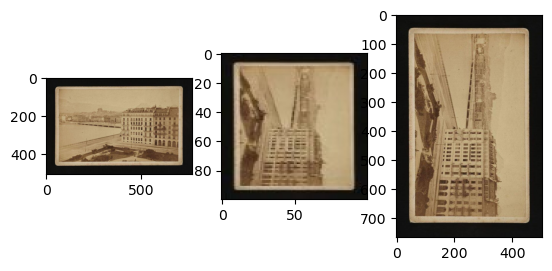

In [51]:
# Votre réponse ici

fig, ax = plt.subplots(1,3)





response = requests.get("https://framemark.vam.ac.uk/collections/2018LE5619/full/full/0/default.jpg")
image1_fullresolution = Image.open(BytesIO(response.content))

response = requests.get("https://framemark.vam.ac.uk/collections/2018LE5619/full/100,100/90/default.jpg")
image2_100100 = Image.open(BytesIO(response.content))

response = requests.get("https://framemark.vam.ac.uk/collections/2018LE5619/full/full/90/default.jpg")
image3_rotation = Image.open(BytesIO(response.content))

ax[0].imshow(image1_fullresolution)
ax[1].imshow(image2_100100)
ax[2].imshow(image3_rotation)

plt.show()

### Exercice 3

Cas typique de ce qui pourrait être le début de votre projet de recherche, constitutez votre propre corpus. Continuons de prendre ici l'exemple du V&A, avec les objets parisiens entre 1750 et 1760.

Pour cela :
- Triez votre `DataFrame` par ordre alphabétique d'artiste
- Pour les 10 premières images, et téléchargez sur votre machine (dans un dossier spécifique) :
  - Le manifeste JSON de l'objet
  - Une version en haute-résolution couleur de l'objet en PNG
  - Une version grise en basse résolution en JPG
  - ❗ Faites bien attention à garder trace de quel objet il s'agit dans le nom du fichier
- Ajoutez le chemin (path) vers l'image numérique haute-résolution et couleur dans la `DataFrame`
- Exportez ceci en CSV.

In [64]:
df

,accessionNumber,accessionYear,systemNumber,objectType,_primaryTitle,_primaryPlace,_primaryMaker__name,_primaryMaker__association,_primaryDate,_primaryImageId,_sampleMaterial,_sampleTechnique,_sampleStyle,_currentLocation__displayName,_objectContentWarning,_imageContentWarning
0,E.1433-1906,1906.0,O848192,Etching,NaN,Paris,? Janel,Designer,late 18th century,2012FK2799,printing ink,etching,NaN,"Prints & Drawings Study Room, level D",False,False
1,E.1434-1906,1906.0,O848191,Etching,NaN,Paris,? Janel,Designer,late 18th century,2012FK2812,printing ink,etching,NaN,"Prints & Drawings Study Room, level D",False,False
2,E.1435-1906,1906.0,O848190,Etching,NaN,Paris,? Janel,Designer,late 18th century,2012FK2802,printing ink,etching,NaN,"Prints & Drawings Study Room, level D",False,False
3,E.1436-1906,1906.0,O848189,Etching,NaN,Paris,? Janel,Designer,late 18th century,2012FK2804,printing ink,etching,NaN,"Prints & Drawings Study Room, level D",False,False
4,E.1903-1931,1931.0,O748421,Engraving,Cartouches pour être accompagnés de Supports e...,Paris,Babel,Designer,mid 18th century,2013GL7946,printing ink,engraving,NaN,"Prints & Drawings Study Room, level D",False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,130-1865,1865.0,O377130,Wall clock,NaN,Paris,"Mynuel, Louis",clockmaker,01/01/1760-01/01/1860,2006AK6764,horn,marquetry,Louis XIV,in store,False,False
96,E.75-1949,1949.0,O598132,Print,NaN,Paris,Unknown,NaN,mid 18th century,2012FV6013,NaN,engraving,NaN,"Prints & Drawings Study Room, level C",False,False
97,E.79-1949,1949.0,O1029840,Trade card,NaN,Paris,Unknown,NaN,1756,2012FV5999,NaN,engraving,NaN,"Prints & Drawings Study Room, level C",False,False
98,E.897:29-1988,1988.0,O124471,Design,NaN,Paris,Unknown,NaN,ca. 1755,2010EA4354,pencil,Handwriting,NaN,"Prints & Drawings Study Room, level E",False,False


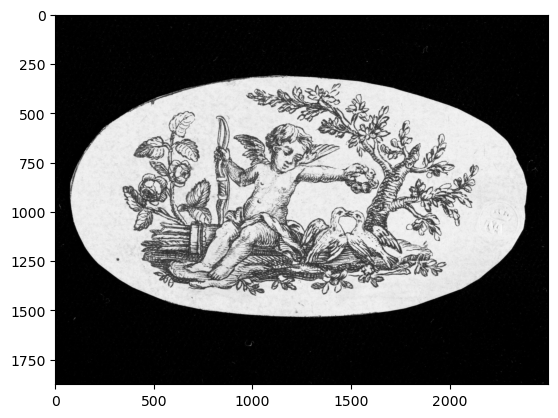

In [85]:
# Votre réponse ici
import json 

# Etape 1. Récupérer les résultats.
df = fonction('q_place_name=paris@&images_exist=1&year_made_from=1750&year_made_to=1760&page_size=100')

# Etape 2. Trier par ordre alphabétique.
#id_place (eg. x28980 pour Londres)
df = df.sort_values('_primaryMaker__name').reset_index(drop=True)

# Etape 3. Télécharger les images et manifestes:

# On itère seulement sur les 10 premières images
for image_id in df['_primaryImageId'].values[:10]:
    
    # Etape 3.1. Télécharger le manifeste
    # Définir l'url
    manifest_url = f"https://framemark.vam.ac.uk/collections/{image_id}/info.json"

    # Récupérer l'objet JSON
    req = requests.get(manifest_url)
    object_data = req.json()

    # Écrire le fichier JSON
    with open(f'./data/{image_id}.json', 'w') as f:
        json.dump(object_data, f)

    # Etape 3.2. Télécharger l'image en pleine résolution. 
    
    response = requests.get(f"https://framemark.vam.ac.uk/collections/{image_id}/full/full/0/default.jpg")
    img = Image.open(BytesIO(response.content))

    plt.imshow(img)
    # Attention: il suffit de modifier la fin de l'url au moment de l'export pour télécharger un PNG
    plt.savefig(f'./data/{image_id}_full.png')

    # Etape 3.3. Télécharger l'image en basse résolution
    response = requests.get(f"https://framemark.vam.ac.uk/collections/{image_id}/full/full/0/gray.jpg")
    img = Image.open(BytesIO(response.content))

    # Ici, on récupère une image à un seul canal (car N/B). Il faut donc l'afficher avec la colormap grise
    plt.imshow(img, cmap='Greys_r')
    plt.savefig(f'./data/{image_id}_gray.jpg')

In [17]:
req = requests.get('https://data.rijksmuseum.nl/202581652')
object_data = req.json()
object_data

{'@context': 'https://linked.art/ns/v1/linked-art.json',
 'id': 'https://id.rijksmuseum.nl/202581652',
 'type': 'VisualItem',
 'subject_to': [{'type': 'Right',
   'identified_by': [{'type': 'Name',
     'content': 'Auteursrecht',
     'language': [{'id': 'http://vocab.getty.edu/aat/300388256',
       'type': 'Language',
       '_label': 'Dutch'}]},
    {'type': 'Name',
     'content': 'Copyright',
     'language': [{'id': 'http://vocab.getty.edu/aat/300388277',
       'type': 'Language',
       '_label': 'English'}]}],
   'classified_as': [{'id': 'https://rightsstatements.org/vocab/InC/1.0/',
     'type': 'Type',
     '_label': 'Copyright'}]}],
 'about': [{'type': 'Period',
   'classified_as': ['http://vocab.getty.edu/aat/300081446'],
   'timespan': {'type': 'TimeSpan',
    'identified_by': [{'type': 'Name',
      'content': '1942-08 - 1943-06',
      'language': [{'id': 'http://vocab.getty.edu/aat/300388277',
        'type': 'Language',
        '_label': 'English'}]},
     {'type': 'N